# Hands-on: Building a Hand Gesture Classifier

In this notebook, we will build a gesture recognition pipeline using hand landmarks extracted from images.

By the end, you will have gone through:

Image -> Hand Landmarks -> Features -> Dataset -> Classifier -> Evaluation -> Unseen Image

### What will you do?

During the workshop, some cells are demonstrations that you can simply run.

Later, you will train and evaluate your own gesture classifier.

Look out for:

👀 **DEMO** — Run and observe

🔍 **EXPLORE** — Change something and see what happens

💻 **YOUR TURN** — Complete part of the code

🚀 **EXTENSION** — Optional challenge

## 0. Setup

Run the following cells to set up the environment. You do not need to modify the code in this section.

### 0.1 Install dependencies

In [15]:
# !pip install -q mediapipe pandas scikit-learn matplotlib opencv-python

### 0.2 Import Libraries

In [21]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    ConfusionMatrixDisplay
)
from pathlib import Path

import mediapipe as mp
import mediapipe.tasks as tasks

NameError: name 'audio_classifier' is not defined

In [20]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\axlee\AppData\Local\Programs\Python\Python312\python.exe
3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]


### 0.3 Download MediaPipe model

This is a pretrained MediaPipe Hand Landmarker model itself.

In [8]:
from pathlib import Path
from urllib.request import urlretrieve

MODEL_PATH = Path("hand_landmarker.task")

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/latest/"
    "hand_landmarker.task"
)

if not MODEL_PATH.exists():
    print("Downloading MediaPipe Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

print("Model ready:", MODEL_PATH.exists())

Model ready: True


In [ ]:
# # Update this path if your folders are located elsewhere
# data_dir = Path("data")
# train_dir = data_dir / "train"
# test_dir = data_dir / "test"

# def collect_image_paths(folder):
#     rows = []
#     for label_dir in sorted(folder.iterdir()):
#         if label_dir.is_dir():
#             for image_path in sorted(label_dir.glob("*")):
#                 if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
#                     rows.append({
#                         "path": str(image_path),
#                         "label": label_dir.name
#                     })
#     return pd.DataFrame(rows)

# train_df = collect_image_paths(train_dir)
# test_df = collect_image_paths(test_dir)

# print(f"Training images: {len(train_df)}")
# print(f"Test images: {len(test_df)}")
# display(train_df.head())
# display(test_df.head())
# print(test_df["label"].value_counts())

## 1. How does a computer see an image?

Before we can recognise a gesture, we first need a useful representation of the hand. 

We will use MediaPipe Hand Landmarker, a pretrained Computer Vision model, to detect 21 keypoints on the hand.

### 1.1 Load our hand image

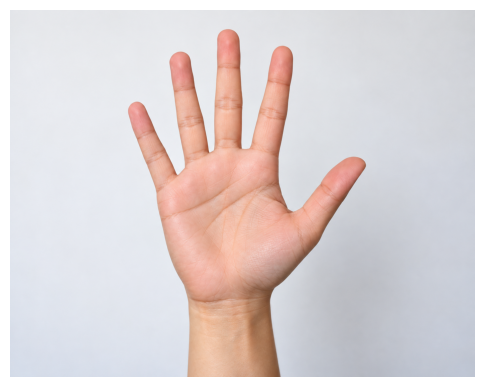

In [12]:
IMAGE_PATH = "../data/workshop images/open_palm.png"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load {IMAGE_PATH}")

# OpenCV loads images in BGR format.
# Convert to RGB for display and MediaPipe.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Why need to convert to RGB? 
# Because OpenCV uses BGR format by default, 
# while most other libraries (like Matplotlib) use RGB format. 
# Converting ensures that the colors are displayed correctly when visualizing the image.

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off") # turn off axis labels and ticks
plt.show()

### 1.2 Configure MediaPipe Hand Landmarker

In [13]:
MODEL_PATH = "hand_landmarker.task"

base_options = tasks.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = tasks.vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

landmarker = tasks.vision.HandLandmarker.create_from_options(
    options
)

NameError: name 'tasks' is not defined

### 1.2 Images are numbers

## 2. From pixels to predictions: image classification

### 2.1 What does classification tell us?

### 2.2 How does a CNN learn visual features?

## 3. From "What" to "Where": Object Detection

### 3.1 Bounding boxes

## 4. How good is a bounding box? IoU

### 4.1 Intersection over union

### 4.2 Calculate IoU

## 5. Why do we need NMS?

### 5.1 Before NMS

### 5.2 Apply NMS

### 5.3 Experiment

## 6. Beyond bounding boxes: segmentation

## 7. From object location to object structure

## 8. Hand landmark detection with MediaPipe

### 8.1 Use a Pretained CV Model

### 8.2 Visualise the 21 landmarks

## 9. Understanding landmark coordinates

### 9.1 Inspect a landmark

### 9.2 From visual structure to numerical features

## 10. Feature engineering for gesture recognition

## 11. From hand landmarks to a gesture dataset

## 12. Train a gesture classifier

### 12.1 Prepare X and y

### 12.2 Train test split

### 12.3 Train random forest

## 13. Evalute the gesture classifier

## 14. Put everything together: unseen image

## 15. Where did your CV system fail?

## 16. Optional Challenges

## 1. From an Image to Hand Landmarks

During the theory session, we saw the keypoint detection identifies important structural points in an image.

For a hand, MediaPipe represents its structure using 21 landmarks.

Let's see what that looks like.

### 1.1 Start with an image

What information would we need to distinguish this from an open palm?

then here can have a small participant interaction 
inspect the landmarks like index by index
ask them change index then see what is the landmark

### 1.2 Extract Hand Landmarks using MediaPipe

## 2. Understanding our Visual Representation

### 2.1 What are the 21 landmarks?

### 2.2 What Information does a Landmark Contain?

### 2.3 From 21 Landmarks to Features

## 3. Feature Engineering

### 3.1 A Problem with Raw Coordinates

### 3.2 Use the Wrist as a Reference Point

### 3.3 Compare Before and After

## 4. Building the Gesture Dataset

### 4.1 Where did our dataset come from?

### 4.2 What does one row represent?

### 4.3 Explore the dataset

## 5. Prepare the data for training

### 5.1 Separate features and labels

### 5.2 Train test split

## 6. Train your gesture classifier

## 7. Test on Unseen Images

## 8. What Went Wrong?

## 9. Extensions